In [1]:
# Cell 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import lightgbm as lgb
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Cell 2: Load the diabetes.csv dataset
df = pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Cell 3: Check for missing values
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


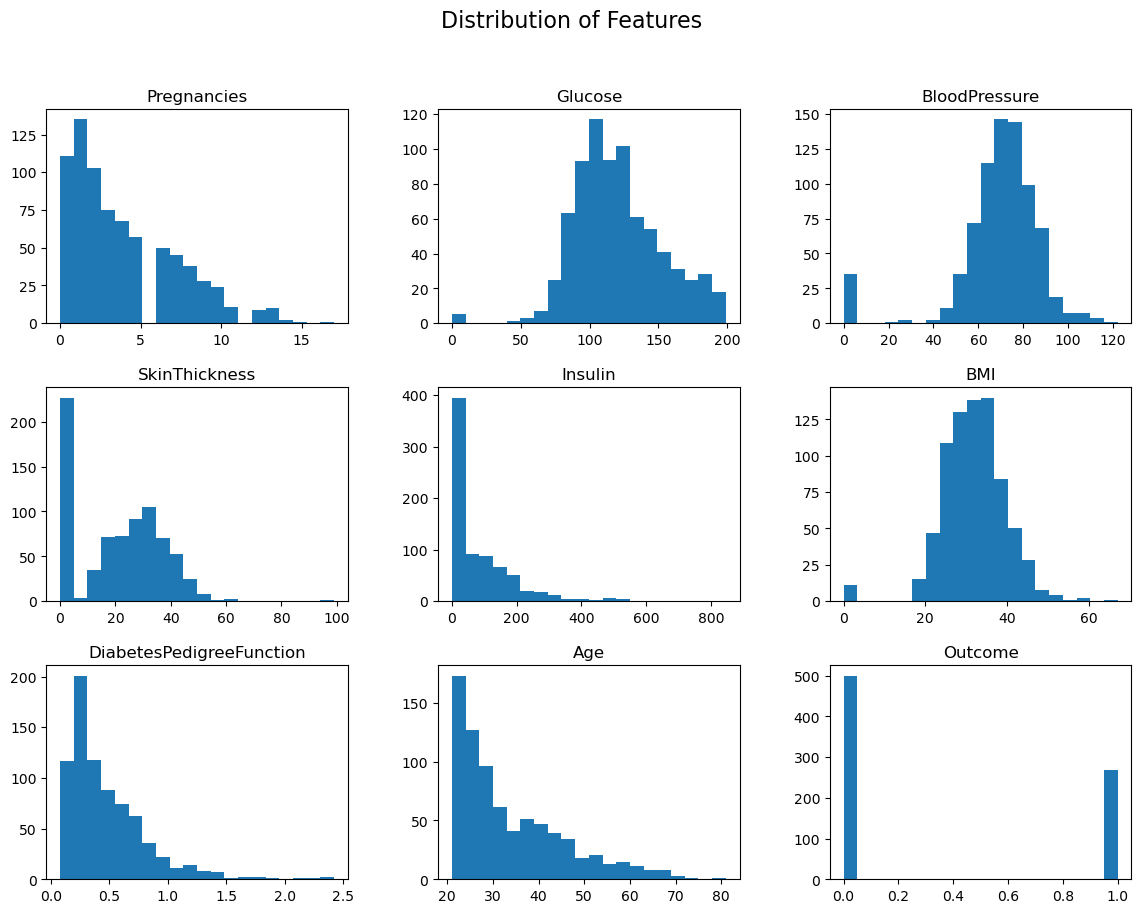

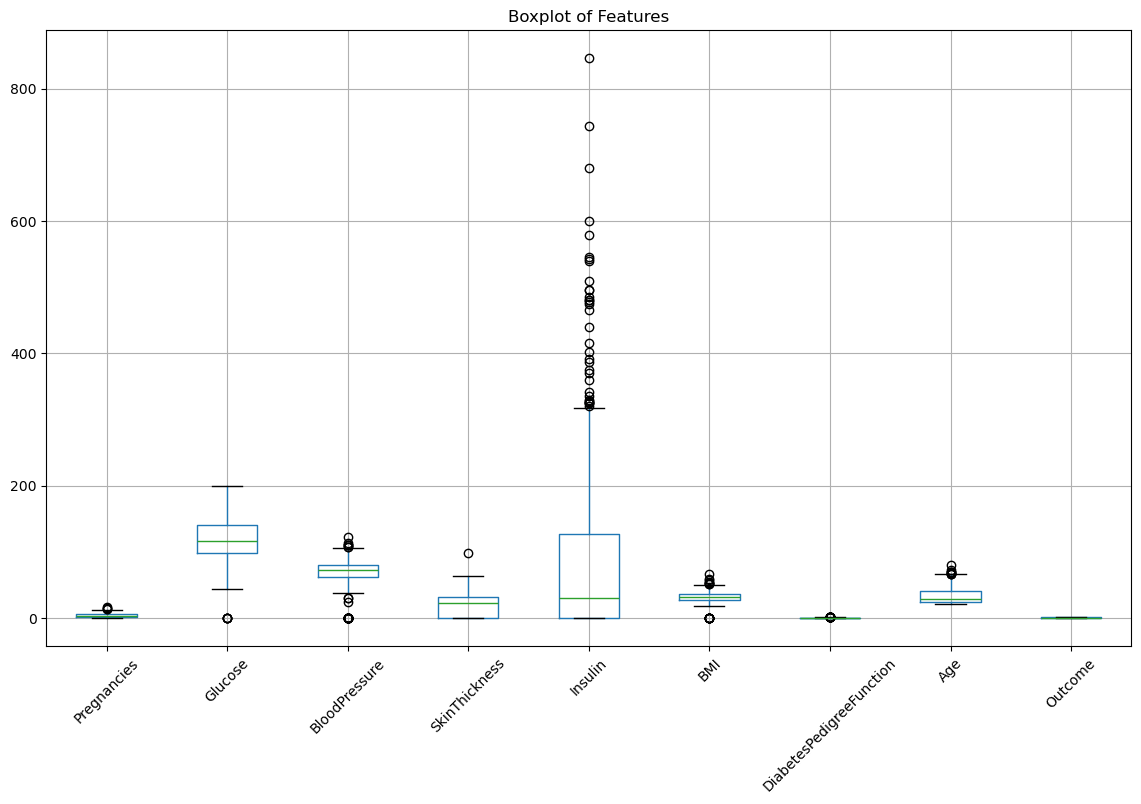

In [4]:
# Cell 4: Histograms
df.hist(bins=20, figsize=(14,10), grid=False)
plt.suptitle('Distribution of Features', fontsize=16)
plt.show()

# Box plots
plt.figure(figsize=(14,8))
df.boxplot()
plt.title('Boxplot of Features')
plt.xticks(rotation=45)
plt.show()


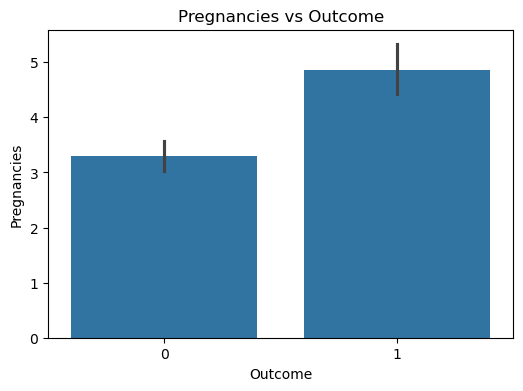

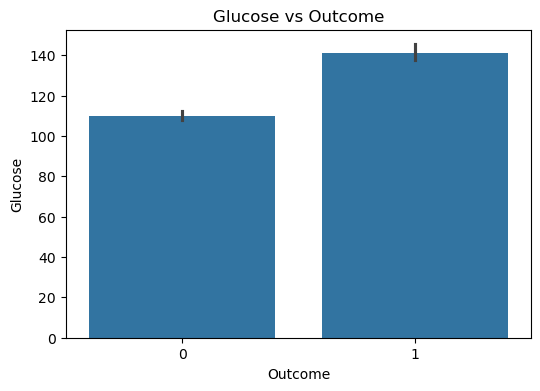

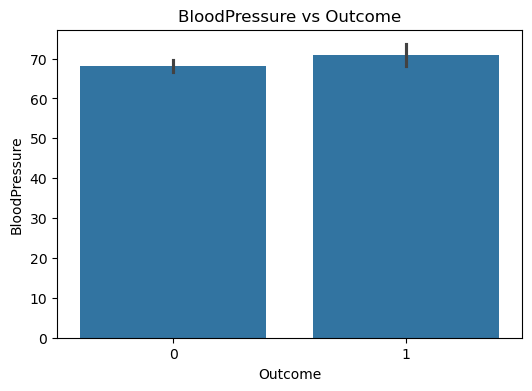

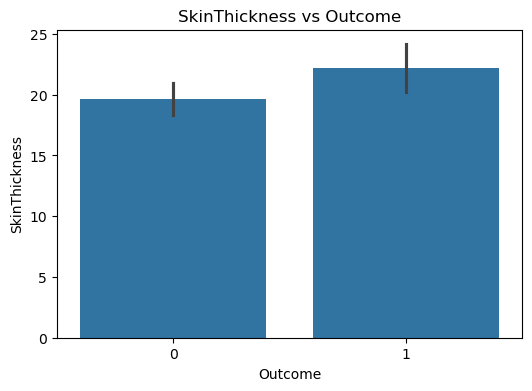

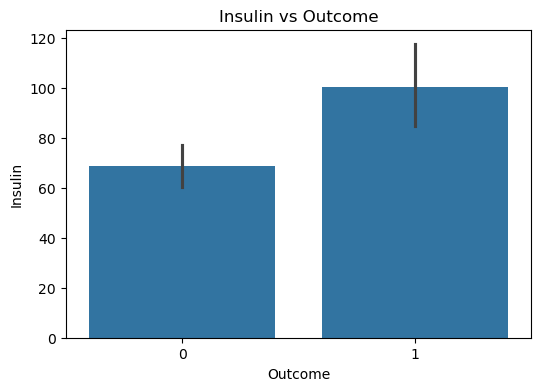

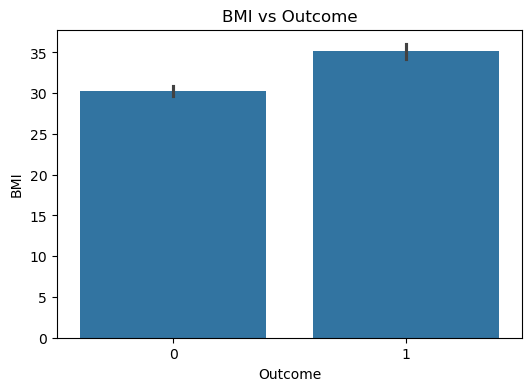

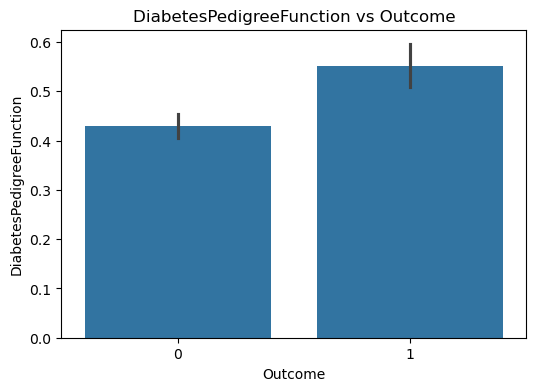

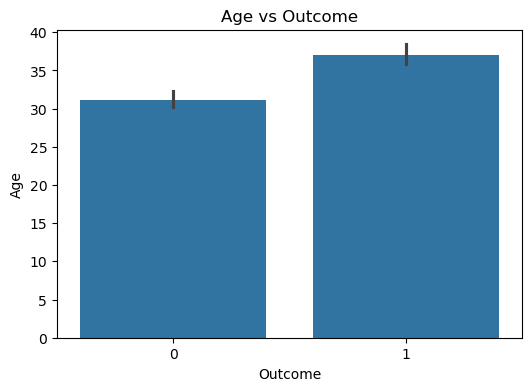

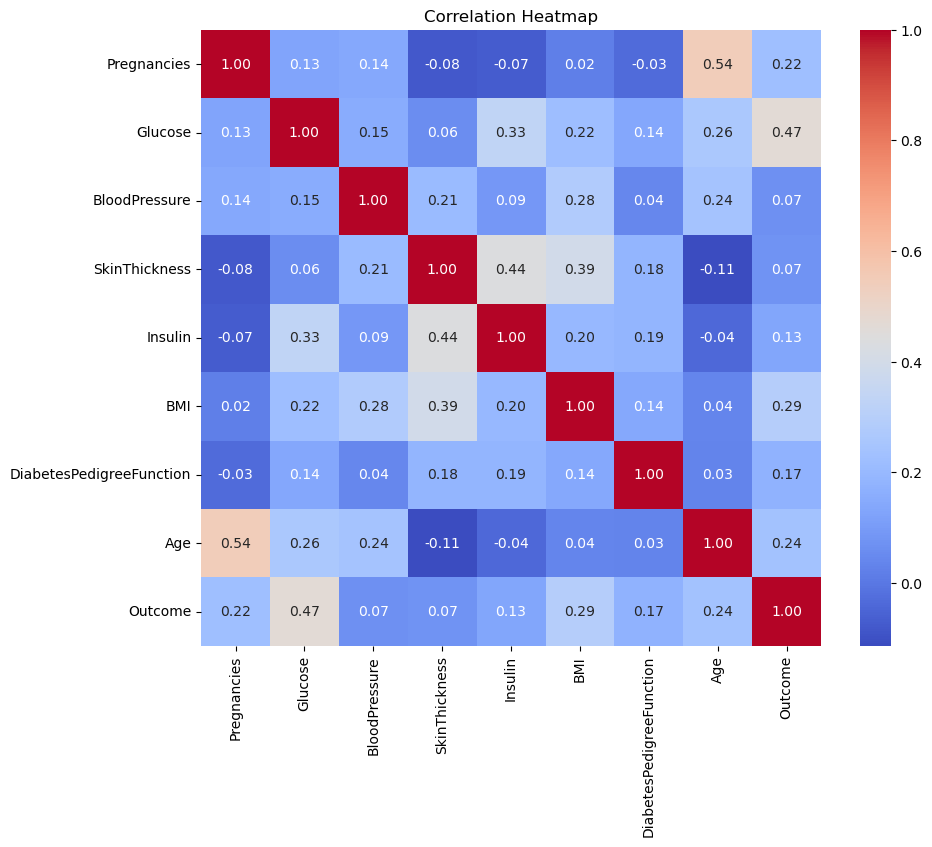

In [5]:
# Cell 5: Feature vs Target Bar Plots
for col in df.columns:
    if col != "Outcome":
        plt.figure(figsize=(6,4))
        sns.barplot(x="Outcome", y=col, data=df)
        plt.title(f'{col} vs Outcome')
        plt.show()

# Feature Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


In [6]:
# Cell 6: Replace possible missing zeros in numeric columns (except Pregnancies/Outcome)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    median = df[col].median()
    df[col].fillna(median, inplace=True)

df.isnull().sum()  # Should all be zero now


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Cell 7: Check types (all features are numeric in this dataset)
df.dtypes


Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
# Cell 8: Split the dataset
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shapes:", X_train.shape, X_test.shape)


Shapes: (614, 8) (154, 8)


In [9]:
# Cell 9: Evaluation Metric Function
def eval_metrics(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_pred_bin = (y_pred >= 0.5).astype(int) if y_pred.max() <= 1 else y_pred
    print(f"\n{model_name} Evaluation Metrics:")
    print("Accuracy:", accuracy_score(y_test, y_pred_bin))
    print("Precision:", precision_score(y_test, y_pred_bin))
    print("Recall:", recall_score(y_test, y_pred_bin))
    print("F1 Score:", f1_score(y_test, y_pred_bin))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bin))
    print("\nClassification Report:\n", classification_report(y_test, y_pred_bin))


In [11]:
# Cell 10: Train LightGBM Model (with sklearn API)
lgbm_clf = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=100,
    random_state=42
)

lgbm_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=10,
    verbose=False
)

# Predict and evaluate
eval_metrics(lgbm_clf, X_test, y_test, "LightGBM")


TypeError: LGBMClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'